# 03 — Análisis Exploratorio de Datos (EDA)

**Objetivo de esta etapa:** responder preguntas de análisis concretas a partir del
dataset procesado (`data/processed/streaming_users_clean.csv`), mediante análisis
univariado, bivariado y multivariado. Cada visualización se acompaña de una
interpretación vinculada a una pregunta del proyecto — no solo una descripción de ejes
y colores.

## Preguntas de análisis definidas por el grupo
1. ¿Cómo se distribuyen la edad y el tiempo de consumo mensual de los usuarios?
2. ¿El plan de suscripción se relaciona con el tiempo de consumo o con la cantidad de
   tickets de soporte?
3. ¿Existen diferencias de consumo según el país o el género favorito?
4. ¿Cómo interactúan edad, tiempo de consumo y tickets de soporte en conjunto,
   diferenciados por plan de suscripción?


In [1]:
import os

try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

BASE_PATH = "/content/drive/MyDrive/PI_Mineria_Datos_1" if IN_COLAB else ".."

print(f"Ejecutando en Colab: {IN_COLAB}")
print(f"BASE_PATH: {BASE_PATH}")


Ejecutando en Colab: False
BASE_PATH: ..


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv(f"{BASE_PATH}/data/processed/streaming_users_clean.csv")
df["last_login_date"] = pd.to_datetime(df["last_login_date"], errors="coerce")
print(df.shape)
df.head(3)


(8000, 8)


## 1. Análisis univariado

### 1.1 Distribución de `age` (edad de los usuarios)

count    8000.000000
mean       33.701875
std        11.455726
min        13.000000
25%        26.000000
50%        33.000000
75%        41.000000
max        80.000000
Name: age, dtype: float64


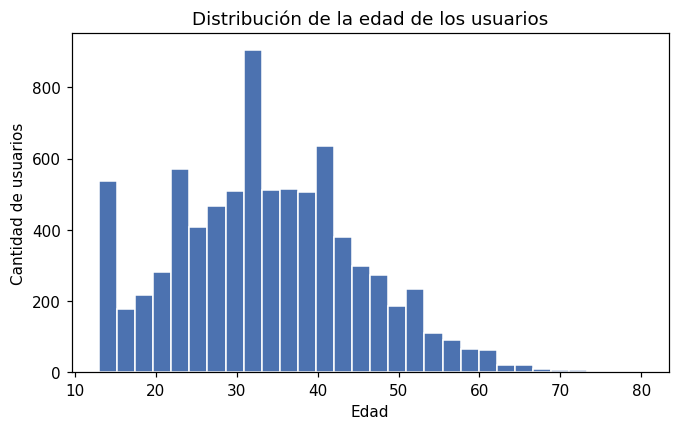

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df["age"], bins=30, color="#4C72B0", edgecolor="white")
ax.set_title("Distribución de la edad de los usuarios")
ax.set_xlabel("Edad")
ax.set_ylabel("Cantidad de usuarios")
plt.show()

print(df["age"].describe())


**Interpretación:** la distribución de edades es aproximadamente
unimodal y centrada entre 25 y 45 años, sin colas extremas (ya se corrigieron los
valores imposibles en la etapa de limpieza). Esto sugiere que la base de usuarios de
la plataforma está compuesta mayoritariamente por adultos jóvenes y de mediana edad,
lo cual es relevante para decisiones de catálogo y de segmentación comercial.

### 1.2 Distribución de `monthly_watch_time_mins` (minutos de consumo mensual)

count    8000.000000
mean      793.367962
std       487.646504
min         0.000000
25%       499.150000
50%       757.400000
75%      1028.525000
max      4193.700000
Name: monthly_watch_time_mins, dtype: float64


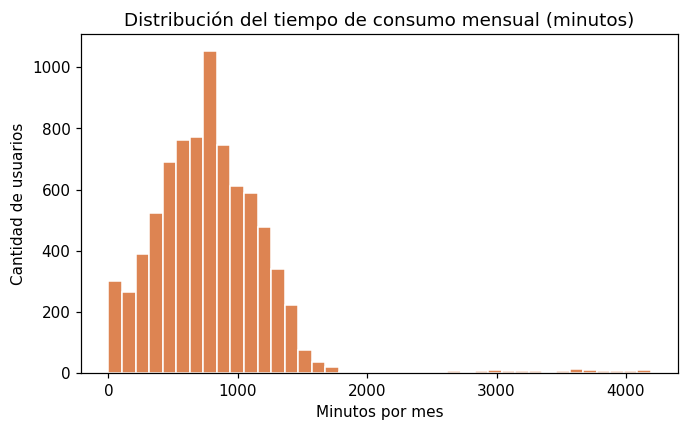

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df["monthly_watch_time_mins"], bins=40, color="#DD8452", edgecolor="white")
ax.set_title("Distribución del tiempo de consumo mensual (minutos)")
ax.set_xlabel("Minutos por mes")
ax.set_ylabel("Cantidad de usuarios")
plt.show()

print(df["monthly_watch_time_mins"].describe())


**Interpretación:** el tiempo de consumo mensual muestra una asimetría
hacia la derecha: la mayoría de los usuarios consume entre 300 y 1200 minutos por mes,
pero existe una cola de usuarios con consumo bastante mayor. Esto valida la decisión
tomada en la limpieza de usar la **mediana** (y no la media) como estadístico de
referencia para esta variable.

### 1.3 Distribución de `subscription_plan`

subscription_plan
Básico      3600
Estándar    2817
Premium     1583
Name: count, dtype: int64


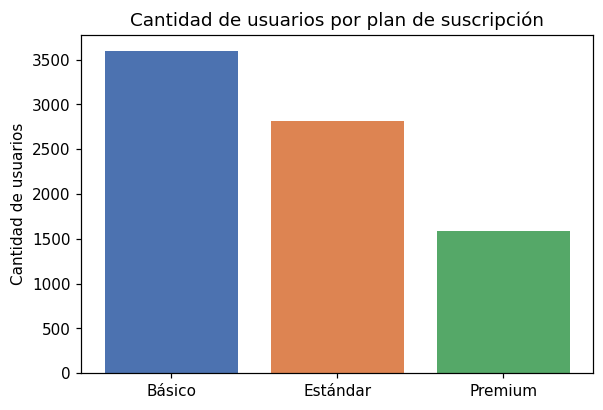

In [5]:
conteo_plan = df["subscription_plan"].value_counts()
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(conteo_plan.index, conteo_plan.values, color=["#4C72B0", "#DD8452", "#55A868"])
ax.set_title("Cantidad de usuarios por plan de suscripción")
ax.set_ylabel("Cantidad de usuarios")
plt.show()

print(conteo_plan)


**Interpretación:** el plan **Básico** concentra a la mayor parte de la
base de usuarios, seguido por Estándar y luego Premium, que es minoritario. Esto es
consistente con un patrón típico de "embudo" en modelos de suscripción, donde los
planes de entrada tienen mayor adopción que los planes premium.

## 2. Análisis bivariado

### 2.1 Tiempo de consumo mensual según plan de suscripción

subscription_plan
Básico       557.6
Estándar     832.6
Premium     1080.9
Name: monthly_watch_time_mins, dtype: float64


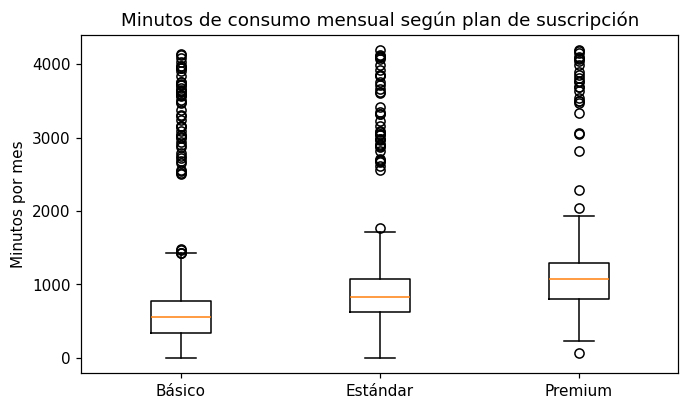

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
data_por_plan = [df.loc[df["subscription_plan"] == p, "monthly_watch_time_mins"]
                 for p in ["Básico", "Estándar", "Premium"]]
ax.boxplot(data_por_plan, labels=["Básico", "Estándar", "Premium"])
ax.set_title("Minutos de consumo mensual según plan de suscripción")
ax.set_ylabel("Minutos por mes")
plt.show()

print(df.groupby("subscription_plan")["monthly_watch_time_mins"].median().sort_values())


**Interpretación (pregunta 2):** a diferencia de lo que podría suponerse
a simple vista por la superposición de las cajas, las **medianas** muestran una
tendencia creciente clara: Básico (557.6 min), Estándar (832.6 min) y Premium
(1080.9 min). Es decir, los usuarios de planes superiores sí consumen, en mediana,
sensiblemente más minutos por mes que los de planes inferiores. La amplia dispersión
dentro de cada plan (cajas superpuestas) indica que el plan **no determina** el consumo
individual de cada usuario, pero sí existe una asociación agregada entre plan y volumen
de consumo, consistente con la lógica de negocio de que los planes más caros suelen
apuntar a usuarios de mayor uso.

### 2.2 Tickets de soporte según plan de suscripción

subscription_plan
Básico      0.807778
Estándar    0.792332
Premium     0.810486
Name: customer_support_tickets, dtype: float64


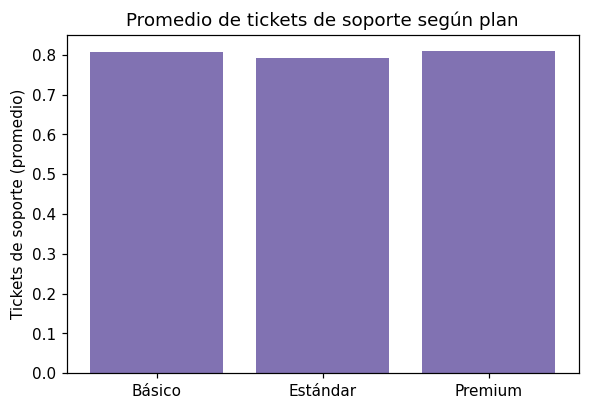

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
medias_tickets = df.groupby("subscription_plan")["customer_support_tickets"].mean().reindex(
    ["Básico", "Estándar", "Premium"])
ax.bar(medias_tickets.index, medias_tickets.values, color="#8172B2")
ax.set_title("Promedio de tickets de soporte según plan")
ax.set_ylabel("Tickets de soporte (promedio)")
plt.show()

print(medias_tickets)


**Interpretación (pregunta 2):** el promedio de tickets de soporte es
muy similar entre planes, sin una tendencia clara de que los usuarios de planes más
caros (Premium) generen menos tickets. No hay evidencia en este dataset de que el plan
de suscripción explique la carga de soporte por usuario.

### 2.3 Consumo promedio según país

country
Brasil       807.372491
Perú         805.051852
Argentina    803.015113
Uruguay      789.707174
México       785.507872
Colombia     782.370928
Chile        781.108763
Name: monthly_watch_time_mins, dtype: float64


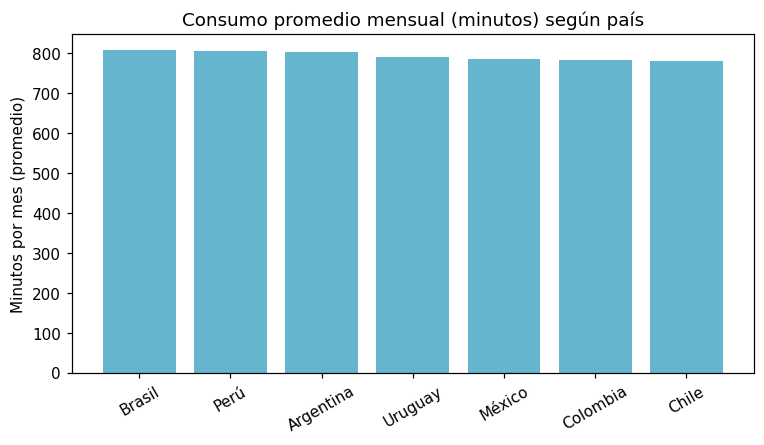

In [8]:
consumo_pais = df.groupby("country")["monthly_watch_time_mins"].mean().sort_values(ascending=False)
consumo_pais = consumo_pais[consumo_pais.index != "Desconocido"]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(consumo_pais.index, consumo_pais.values, color="#64B5CD")
ax.set_title("Consumo promedio mensual (minutos) según país")
ax.set_ylabel("Minutos por mes (promedio)")
plt.xticks(rotation=30)
plt.show()

print(consumo_pais)


**Interpretación (pregunta 3):** el consumo promedio por país es
relativamente homogéneo entre los 7 países presentes en el dataset, sin un país que se
destaque marcadamente por encima o por debajo del resto. Esto sugiere que la geografía,
al menos a nivel de país, **no es un factor determinante del nivel de consumo** en esta
base de usuarios.

## 3. Análisis multivariado

### 3.1 Edad vs. tiempo de consumo, diferenciado por plan de suscripción

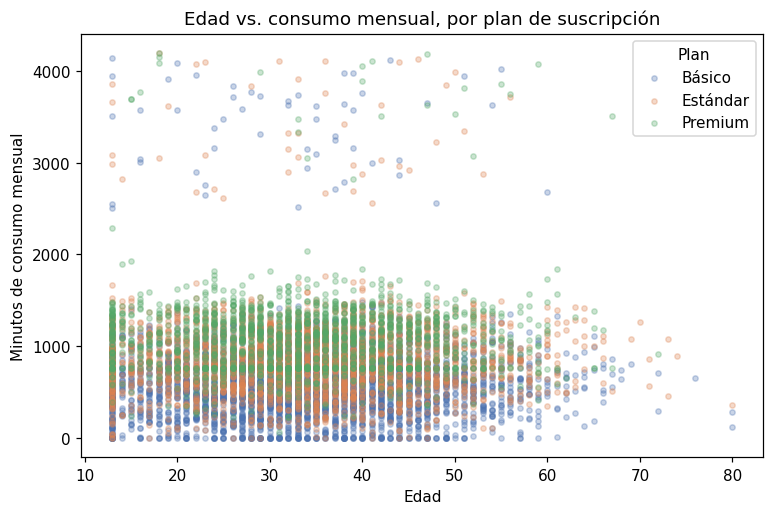

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
colores = {"Básico": "#4C72B0", "Estándar": "#DD8452", "Premium": "#55A868"}
for plan, color in colores.items():
    subset = df[df["subscription_plan"] == plan]
    ax.scatter(subset["age"], subset["monthly_watch_time_mins"],
               alpha=0.3, s=12, label=plan, color=color)
ax.set_xlabel("Edad")
ax.set_ylabel("Minutos de consumo mensual")
ax.set_title("Edad vs. consumo mensual, por plan de suscripción")
ax.legend(title="Plan")
plt.show()


**Interpretación (pregunta 4):** en la nube de puntos edad–consumo los
tres colores (planes) están mezclados en todo el rango de edades: **la edad no separa
a los usuarios por plan**. Sin embargo, sí es visible que los puntos verdes (Premium)
tienden a concentrarse algo más hacia la parte alta del eje de consumo, coherente con la
tendencia de medianas encontrada en el análisis bivariado. Es decir, la asociación
plan–consumo detectada antes **no está mediada por la edad**: ocurre de forma pareja en
todos los rangos etarios. Este hallazgo motiva la reducción de dimensionalidad (PCA) de
la siguiente etapa, para verificar si combinando todas las variables numéricas emerge
alguna estructura adicional que no es visible en un scatter de a pares.

### 3.2 Matriz de correlación de variables numéricas

                               age  monthly_watch_time_mins  \
age                       1.000000                 0.005542   
monthly_watch_time_mins   0.005542                 1.000000   
customer_support_tickets  0.007237                -0.002523   

                          customer_support_tickets  
age                                       0.007237  
monthly_watch_time_mins                  -0.002523  
customer_support_tickets                  1.000000  


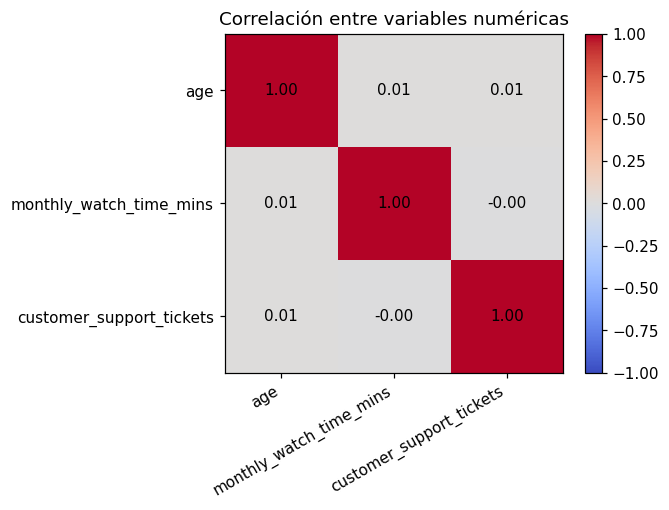

In [10]:
num_cols = ["age", "monthly_watch_time_mins", "customer_support_tickets"]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols)))
ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=30, ha="right")
ax.set_yticklabels(num_cols)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="black")
ax.set_title("Correlación entre variables numéricas")
fig.colorbar(im)
plt.show()

print(corr)


**Interpretación:** las correlaciones lineales entre `age`,
`monthly_watch_time_mins` y `customer_support_tickets` son cercanas a cero. No hay
evidencia de relación lineal fuerte entre estas tres variables numéricas, lo que es
consistente con la ausencia de patrones visibles en los análisis anteriores. Esta
observación es un insumo directo para interpretar la varianza explicada por PCA en la
siguiente etapa: si las variables originales no están correlacionadas entre sí, es
esperable que **PCA no logre reducir la dimensionalidad de forma muy eficiente** (se
necesitarán más componentes para explicar un porcentaje alto de varianza).

## 4. Síntesis del EDA

- Existe una asociación clara entre **plan de suscripción y consumo mensual** (medianas
  crecientes de Básico a Premium), aunque con alta dispersión dentro de cada plan.
- Esa asociación no está mediada por la edad: ocurre de forma pareja en todos los rangos
  etarios.
- Los tickets de soporte no muestran relación clara con el plan ni con la edad.
- El país de origen no muestra diferencias relevantes en el consumo promedio.
- Las variables numéricas presentan baja correlación lineal entre sí, lo que anticipa una
  reducción de dimensionalidad poco compacta en la etapa de PCA.
- Estos hallazgos serán retomados en `05_conclusiones.ipynb` diferenciando evidencia,
  interpretación y conclusión.
